# LoRA: Low-Rank Adaptation of Large Language Models

Hu, Shen, Wallis, Allen-Zhu, Li, Wang, Wang, Chen — ICLR 2022. [Paper PDF](LoRA%20-%20Low-Rank%20Adaptation%20of%20Large%20Language%20Models.pdf)

**The problem:** fine-tuning a large pretrained model on a new task usually means updating
every parameter — expensive in compute, memory (optimizer state for every parameter), and
storage (a full copy of the model per task).

**The idea:** freeze the pretrained weight matrix `W` entirely, and learn a small additive
correction instead: `delta_W = (alpha/r) * A @ B`, where `A` is `in_features x r`, `B` is
`r x out_features`, and `r` (here, 8) is far smaller than the matrix's actual dimensions. Only
`A` and `B` get gradients:

$$h = xW + \frac{\alpha}{r} \cdot x A B$$

At initialization, `A` is small random noise and `B` is exactly zero, so `delta_W = 0` and the
adapted model starts out identical to the frozen base model — training only ever moves the
adapter away from a no-op, never starts from a random perturbation.

**Where it's applied:** the paper's own ablation finds adapting just the query and value
projections (`Wq`, `Wv`) is more effective than spreading the same parameter budget across all
four attention matrices, so that's what this notebook does — GPT-2 fuses q/k/v into one `c_attn`
matrix, so the adapter here targets the query and value thirds of its output, leaving the key
third untouched.

This notebook implements the mechanism from scratch (see `model.py`, `train.py` — no `peft`
library) and fine-tunes DistilGPT-2 on tiny Shakespeare two ways: full fine-tuning (every
parameter trainable) vs. LoRA (only ~0.1% of parameters trainable), comparing trainable
parameter count, checkpoint size, training time/memory, loss curves, and generated text.

In [1]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, GPT2LMHeadModel

from model import setup_lora_model, trainable_parameter_count, total_parameter_count
from train import compute_loss, current_memory_mb, evaluate, save_checkpoint, save_lora_adapters, train_step

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("results", exist_ok=True)

Using device: mps


## Base model

DistilGPT-2: 82M parameters, 6 transformer layers, hidden size 768. Before any fine-tuning,
here's what it generates for a Shakespeare-flavored prompt — plain modern-sounding text, as
expected from a model pretrained on general web text.

In [2]:
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

PROMPT = "ROMEO:\nWhat light through yonder window breaks?"


def generate_sample(model, prompt: str = PROMPT, max_new_tokens: int = 40) -> str:
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)


base_model_for_sample = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)
print(generate_sample(base_model_for_sample))
print(f"\nTotal parameters: {total_parameter_count(base_model_for_sample):,}")
del base_model_for_sample

ROMEO:
What light through yonder window breaks?
I'm not sure what to do with the light.
I'm not sure what to do with the light.
I'm not sure what to do with the light.
I'm not

Total parameters: 81,912,576


## Tiny Shakespeare

472 train / 49 test rows (~1.2M characters). Tokenize and concatenate, then chunk into fixed
128-token blocks for causal language modeling — no padding needed since every block is full.

In [3]:
BLOCK_SIZE = 128
BATCH_SIZE = 8

raw = load_dataset("Trelis/tiny-shakespeare")


class BlockDataset(Dataset):
    def __init__(self, texts: list[str], block_size: int):
        full_text = "\n\n".join(texts)
        token_ids = tokenizer(full_text)["input_ids"]
        n_blocks = len(token_ids) // block_size
        self.examples = [token_ids[i * block_size:(i + 1) * block_size] for i in range(n_blocks)]

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ids = torch.tensor(self.examples[idx], dtype=torch.long)
        return {"input_ids": ids, "attention_mask": torch.ones_like(ids)}


train_set = BlockDataset(raw["train"]["Text"], BLOCK_SIZE)
test_set = BlockDataset(raw["test"]["Text"], BLOCK_SIZE)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train blocks: {len(train_set)}, Test blocks: {len(test_set)}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Token indices sequence length is longer than the specified maximum sequence length for this model (369582 > 1024). Running this sequence through the model will result in indexing errors


Train blocks: 2887, Test blocks: 302


## Fine-tuning: full vs. LoRA

Same data, same number of epochs — the only difference is which parameters are trainable and
the learning rate (LoRA uses a higher LR since it's only updating a small adapter). Both runs
save per-step metrics, a checkpoint, and a generation sample after every epoch, so nothing here
requires a retrain to analyze later.

In [4]:
EPOCHS = 3


def run_finetune(mode: str):
    assert mode in ("full", "lora")
    torch.manual_seed(0)
    model = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)

    lora_modules = None
    if mode == "lora":
        lora_modules = setup_lora_model(model, r=8, alpha=16)
        lora_modules = [m.to(device) for m in lora_modules]
        lr = 3e-4
    else:
        lr = 5e-5

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)

    history = {"step": [], "loss": [], "time_seconds": [], "memory_mb": []}
    if mode == "lora":
        history["delta_norm"] = []
    eval_history = {"epoch": [], "test_loss": []}
    samples = []

    step = 0
    for epoch in range(EPOCHS):
        for batch in train_loader:
            stats = train_step(model, batch, optimizer, device)
            history["step"].append(step)
            history["loss"].append(stats["loss"])
            history["time_seconds"].append(stats["time_seconds"])
            history["memory_mb"].append(current_memory_mb())
            if mode == "lora":
                history["delta_norm"].append(float(np.mean([m.delta_norm() for m in lora_modules])))
            step += 1

        eval_stats = evaluate(model, test_loader, device)
        eval_history["epoch"].append(epoch + 1)
        eval_history["test_loss"].append(eval_stats["loss"])
        sample = generate_sample(model)
        samples.append({"epoch": epoch + 1, "text": sample})
        print(f"[{mode}] epoch {epoch + 1}/{EPOCHS} test_loss={eval_stats['loss']:.3f}")
        print(f"  sample: {sample!r}")

    with open(f"results/{mode}_history.json", "w") as f:
        json.dump(history, f)
    with open(f"results/{mode}_eval_history.json", "w") as f:
        json.dump(eval_history, f)
    with open(f"results/{mode}_samples.json", "w") as f:
        json.dump(samples, f)

    if mode == "lora":
        save_lora_adapters(lora_modules, "results/lora_adapter.pt")
    else:
        save_checkpoint(model, "results/full_finetune.pt")

    return model, history, eval_history, samples


full_model, full_history, full_eval_history, full_samples = run_finetune("full")

[full] epoch 1/3 test_loss=3.681
  sample: "ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nI'll not, sir, but I'll see it.\n\nKING RICHARD III:\nI'll see it.\n\nKING RICHARD III:"


[full] epoch 2/3 test_loss=3.624
  sample: "ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nThe light of the sun,\nWhich, in the sun, is the sun's light.\n\nROMEO:\nThe light of the sun, in the sun"


[full] epoch 3/3 test_loss=3.612
  sample: 'ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nA light that shines through the night,\nAnd shines through the night.\n\nROMEO:\nA light that shines through the night,\nAnd shines through the'


In [5]:
lora_model, lora_history, lora_eval_history, lora_samples = run_finetune("lora")

[lora] epoch 1/3 test_loss=4.006
  sample: 'ROMEO:\nWhat light through yonder window breaks?\n\nLUCIUS:\nI am not a man, but a man.\n\nLUCIUS:\nI am not a man, but a man.\n\nLUC'


[lora] epoch 2/3 test_loss=3.958
  sample: 'ROMEO:\nWhat light through yonder window breaks?\n\nKING LOUIS:\nI am not a man, but a man.\n\nKING LOUIS:\nI am not a man, but a man.\n\nKING L'


[lora] epoch 3/3 test_loss=3.927
  sample: 'ROMEO:\nWhat light through yonder window breaks?\n\nKING RICHARD II:\nI am not a man, but a man.\n\nKING RICHARD II:\nI am not a man, but a man.\n\n'


## The headline numbers: parameters and storage

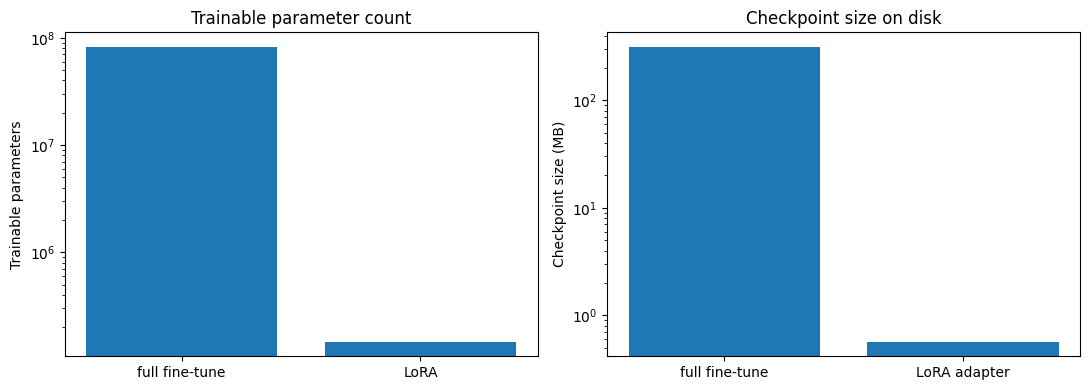

Total model parameters: 82,060,032
Full fine-tune trainable: 81,912,576 (99.8%)
LoRA trainable: 147,456 (0.180%)
Reduction: 556x fewer trainable parameters
Checkpoint size: full=312.5MB, LoRA adapter=0.57MB


In [6]:
full_trainable = trainable_parameter_count(full_model)
lora_trainable = trainable_parameter_count(lora_model)
total_params = total_parameter_count(lora_model)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["full fine-tune", "LoRA"], [full_trainable, lora_trainable])
axes[0].set_ylabel("Trainable parameters")
axes[0].set_title("Trainable parameter count")
axes[0].set_yscale("log")

full_ckpt_mb = os.path.getsize("results/full_finetune.pt") / (1024 ** 2)
lora_ckpt_mb = os.path.getsize("results/lora_adapter.pt") / (1024 ** 2)
axes[1].bar(["full fine-tune", "LoRA adapter"], [full_ckpt_mb, lora_ckpt_mb])
axes[1].set_ylabel("Checkpoint size (MB)")
axes[1].set_title("Checkpoint size on disk")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

print(f"Total model parameters: {total_params:,}")
print(f"Full fine-tune trainable: {full_trainable:,} ({full_trainable/total_params*100:.1f}%)")
print(f"LoRA trainable: {lora_trainable:,} ({lora_trainable/total_params*100:.3f}%)")
print(f"Reduction: {full_trainable/lora_trainable:.0f}x fewer trainable parameters")
print(f"Checkpoint size: full={full_ckpt_mb:.1f}MB, LoRA adapter={lora_ckpt_mb:.2f}MB")

## Training loss, speed, and memory

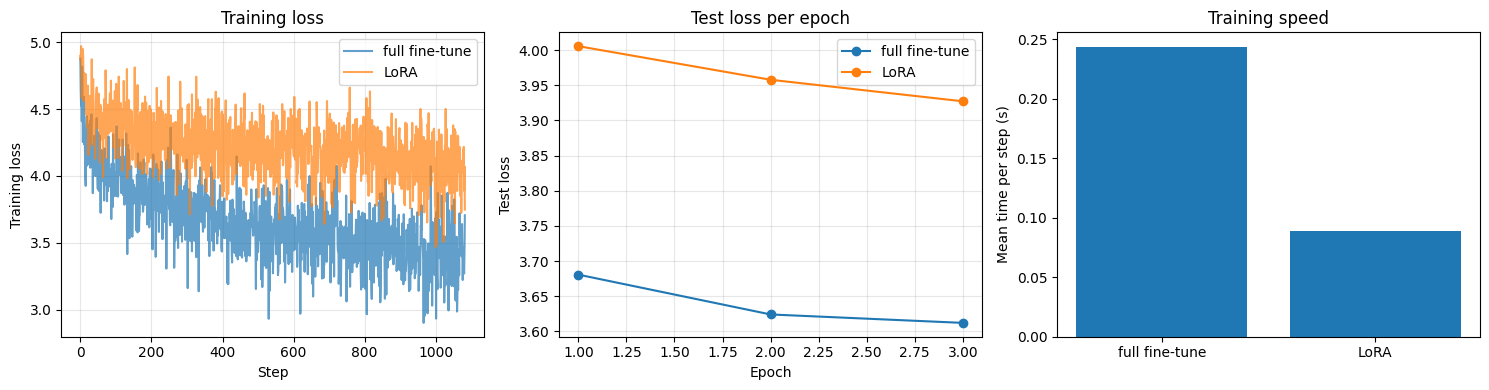

Mean memory (MB) - full: 1435.9, LoRA: 1015.9


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(full_history["step"], full_history["loss"], label="full fine-tune", alpha=0.7)
axes[0].plot(lora_history["step"], lora_history["loss"], label="LoRA", alpha=0.7)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Training loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(full_eval_history["epoch"], full_eval_history["test_loss"], marker="o", label="full fine-tune")
axes[1].plot(lora_eval_history["epoch"], lora_eval_history["test_loss"], marker="o", label="LoRA")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test loss")
axes[1].set_title("Test loss per epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(
    ["full fine-tune", "LoRA"],
    [np.mean(full_history["time_seconds"]), np.mean(lora_history["time_seconds"])],
)
axes[2].set_ylabel("Mean time per step (s)")
axes[2].set_title("Training speed")
plt.tight_layout()
plt.show()

print(f"Mean memory (MB) - full: {np.mean(full_history['memory_mb']):.1f}, LoRA: {np.mean(lora_history['memory_mb']):.1f}")

## How far does the adapter move from zero?

At initialization, `delta_W = A @ B = 0` exactly (`B` starts at zero) — the LoRA-adapted model
starts out identical to the frozen base. Training moves it away from that no-op.

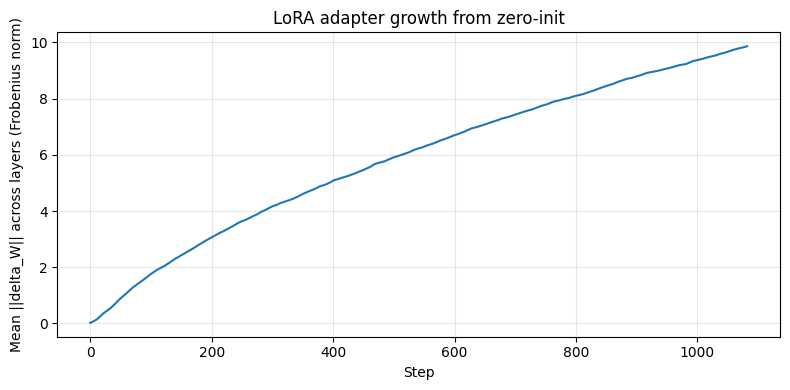

delta_norm at step 0: 0.0184
delta_norm at final step: 9.8661


In [8]:
plt.figure(figsize=(8, 4))
plt.plot(lora_history["step"], lora_history["delta_norm"])
plt.xlabel("Step")
plt.ylabel("Mean ||delta_W|| across layers (Frobenius norm)")
plt.title("LoRA adapter growth from zero-init")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"delta_norm at step 0: {lora_history['delta_norm'][0]:.4f}")
print(f"delta_norm at final step: {lora_history['delta_norm'][-1]:.4f}")

## What the models actually generate

Same prompt (`"ROMEO:\nWhat light through yonder window breaks?"`), continuation from each
model at the end of every epoch.

In [9]:
print("=== Full fine-tune ===")
for s in full_samples:
    print(f"[epoch {s['epoch']}] {s['text']!r}")

print("\n=== LoRA ===")
for s in lora_samples:
    print(f"[epoch {s['epoch']}] {s['text']!r}")

=== Full fine-tune ===
[epoch 1] "ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nI'll not, sir, but I'll see it.\n\nKING RICHARD III:\nI'll see it.\n\nKING RICHARD III:"
[epoch 2] "ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nThe light of the sun,\nWhich, in the sun, is the sun's light.\n\nROMEO:\nThe light of the sun, in the sun"
[epoch 3] 'ROMEO:\nWhat light through yonder window breaks?\n\nROMEO:\nA light that shines through the night,\nAnd shines through the night.\n\nROMEO:\nA light that shines through the night,\nAnd shines through the'

=== LoRA ===
[epoch 1] 'ROMEO:\nWhat light through yonder window breaks?\n\nLUCIUS:\nI am not a man, but a man.\n\nLUCIUS:\nI am not a man, but a man.\n\nLUC'
[epoch 2] 'ROMEO:\nWhat light through yonder window breaks?\n\nKING LOUIS:\nI am not a man, but a man.\n\nKING LOUIS:\nI am not a man, but a man.\n\nKING L'
[epoch 3] 'ROMEO:\nWhat light through yonder window breaks?\n\nKING RICHARD II:\nI am not a man, but a man